In [1]:
import os
import glob
import pandas as pd
import numpy as np
from scipy import signal
import soundfile as sf
import matplotlib.pyplot as plt
import funciones as fn

In [43]:
# Constantes  
G = 10**(3/10)     # Cociente de octava base 10: frec * G = octava de frec. G_10 approx= 2. Ver definicion en norma 61260
fs = 44100     # frec de muestreo
f_r = 1000     # Hz, frec de referencia
# f_m_octava = [G**i * f_r for i in range(-5, 5)]     # frecs centrales para anchos de banda de octava
f_m_tercios = [G**(i/3) * f_r for i in range(-10, 2)]     # frecs centrales para anchos de banda de tercio de octava
N = 10     # Orden de los filtros

 - Filtrar el audio por bandas y guardar el valor (N°Mic=Ang Vertical, Ang Horizontal, Frec, dB) en un csv.
 - Recorrer el o los csv prara obtener un slice de la esfera. 
 - Ver como se arma el ballon

In [44]:
path_wavs_cris = os.path.join('.', 'Medicion_Cristian', 'Media')
wavs_cris = np.array(glob.glob(os.path.join(path_wavs_cris, '*.wav')))
wavs_cris_mic_1 = wavs_cris[['mic_1_ang' in os.path.basename(wav) for wav in wavs_cris]]

In [45]:
filtros_tercio = fn.sos_filter_bank(3, f_m_tercios, N, fs, G)

In [121]:
file_prefix = 'mic_1_ang_'
res = []
for i in range(0, 181, 10):
    wav_path = os.path.join(path_wavs_cris, f'{file_prefix}{i}.wav')
    wav, fs_wav = sf.read(wav_path)
    wav_por_tercios = fn.sos_filter_audio(wav, *filtros_tercio)
    wav_tercios_spl = [fn.signal_to_SPL(wav_ter) for wav_ter in wav_por_tercios]
    wav_tercios_leq = [fn.Leq(wav_ter_spl) for wav_ter_spl in wav_tercios_spl]
    for j in range(len(f_m_tercios)):
        res.append((1, 0, i, f_m_tercios[j], wav_tercios_leq[j]))
    # res.append([(1, 0, i, f_m_tercios[j], wav_tercios_leq[j]) for j in range(len(f_m_tercios))])

In [123]:
df = pd.DataFrame(res, columns=['Mic', 'Ang Ver', 'Ang Hor', 'Frec Banda', 'SPL'])
df

,Mic,Ang Ver,Ang Hor,Frec Banda,SPL
0,1,0,0,100.000000,21.070010
1,1,0,0,125.892541,37.125834
2,1,0,0,158.489319,41.075322
3,1,0,0,199.526231,45.623324
4,1,0,0,251.188643,40.251332
...,...,...,...,...,...
223,1,0,180,501.187234,42.356380
224,1,0,180,630.957344,47.030302
225,1,0,180,794.328235,51.165080
226,1,0,180,1000.000000,44.813981


In [ ]:
polar_100 = df[df['Frec Banda'] == 100]
angles = polar_100['Ang Hor'].values
rad = np.deg2rad(angles)
spl = polar_100['SPL'].values

C:\Users\NACHO\AppData\Local\Temp\ipykernel_17220\249430497.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


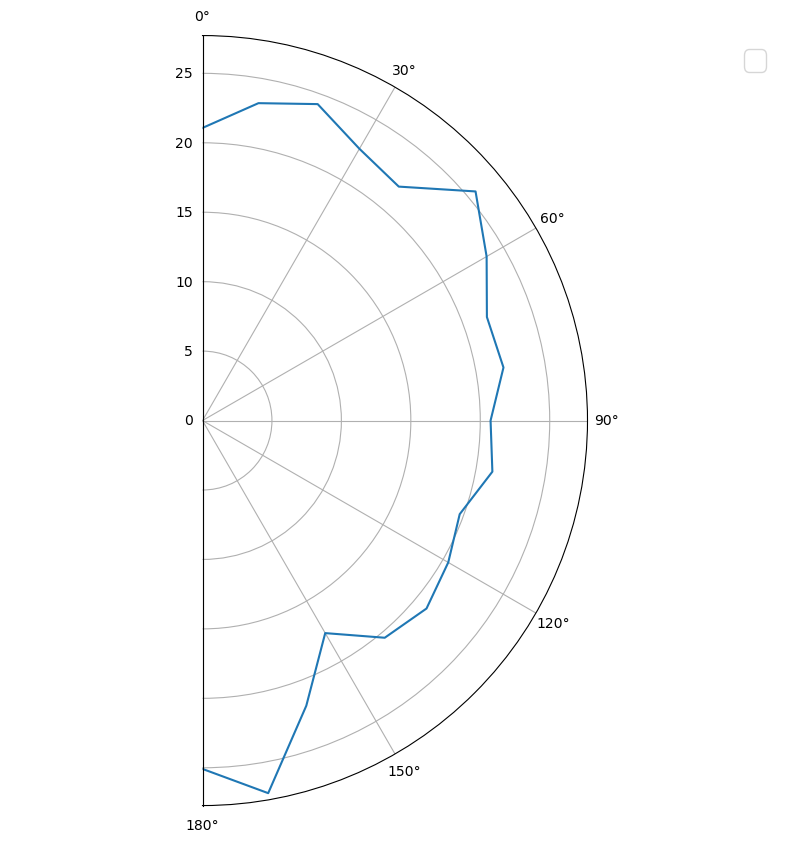

In [129]:
# Create a polar plot
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(projection='polar')
ax.set_theta_direction(-1)  # Dirección en sentido horario
ax.set_theta_offset(np.pi / 2.0)  # Desplazar para que 0º esté en la parte superior
ax.set_thetamin(0)
ax.set_thetamax(180)
# ax.set_rticks([-20,-15,-10,-5, 0])
# ax.set_ylim(-19, 1)
plt.polar(rad, spl)
# plt.polar(rad, radii2,'r',label='250Hz')
# plt.polar(rad, radii3,'b',label='1kHz')
# plt.polar(rad, radii4,'g',label='4kHz')
plt.legend(fontsize=20)
#plt.title("Patrón Cardioide - RODE NT2000", fontsize = 20)
plt.show()
# fig.savefig("Patron_polar_Vigoole_1.jpg")

### Ploteo de los filtros

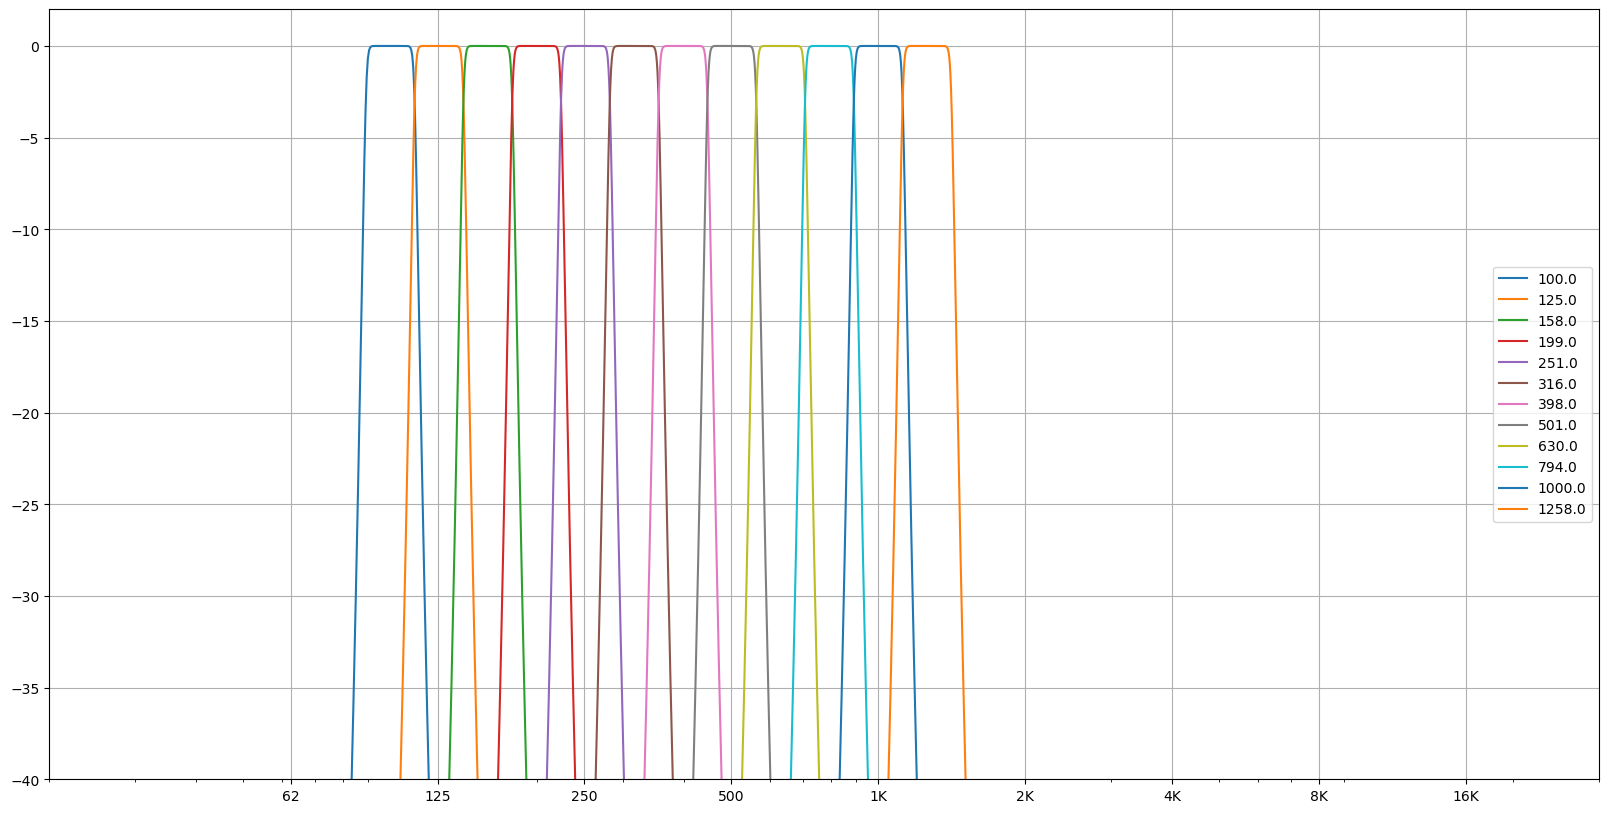

In [48]:
Hs = []
eps = np.finfo(float).eps
for sos in filtros_tercio:
    Wn, H = signal.sosfreqz(sos, fs=fs, worN=fs)
    Hs.append(H)

plt.figure(figsize=(20,10))
for i in range(len(Hs)):
    plt.plot(Wn, 20*np.log10(abs(Hs[i])+eps), label=np.floor(f_m_tercios[i]))
x_ticks = [62.5*2**(n) for n in range(9)]
x_labels = ['62', '125', '250', '500'] + [str(2**(n)) + 'K' for n in range(5)]

plt.xscale('log')
plt.xticks(x_ticks, x_labels)
plt.xlim(20, 30000)
plt.ylim(-40, 2)
plt.legend(loc='right')
plt.grid()

### Plot y Play señal filtrada

501.18723362727235


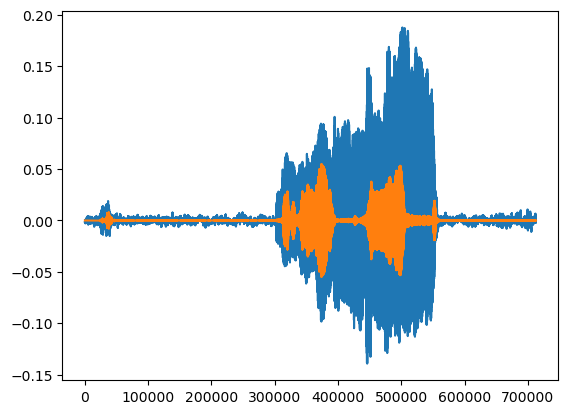

In [101]:
plt.plot(wav)
# for i in range(len(filtros_tercio)):
idx = 7
plt.plot(wav_por_tercios[idx])
print(f_m_tercios[idx])

In [66]:
from IPython.display import Audio

In [69]:
Audio(wav_por_tercios[idx], rate=fs_wav, normalize=True)

In [70]:
Audio(wav, rate=fs_wav, normalize=True)